In [2]:
#@title # Model #8: 1D+3D Graph (ESM-2 node features + structure contact-map edges) + GraphSAGE
# =============================================================================
# Part of the InterPET ablation table:
#   1. 1D, ESM-2, XGBoost   (already done)
#   2. 1D, ESM-2, RF        (already done)
#   3. 1D, ProtT5, XGBoost  (already done)
#   4. 1D, ProtT5, RF       (already done)
#   5. 1D, AAC/CTD, XGBoost (already done)
#   6. 1D, AAC/CTD, RF      (already done)
#   7. 1D, Graph (chain edges), GraphSAGE            (already done)
#   8. 1D+3D, Graph (structure contact-map edges), GraphSAGE   <- this notebook
#
# Model #8 uses the SAME node features (ESM-2 per-residue embeddings) and
# the SAME subset of sequences as Model #7, but replaces the chain edges
# with a 3D structural CONTACT MAP: an edge is drawn between residues i, j
# whenever their C-alpha atoms are within 8 Angstrom in the (experimental
# or ESMFold-predicted) 3D structure. Comparing Model #7 vs #8 isolates
# the value added by 3D structural information for the GNN, analogous to
# how Model #1-6 isolate embedding choice and classifier choice.
#
# NODE FEATURE REUSE: Model #8 reuses Model #7's cached ESM-2 per-residue
# embeddings when available (same reuse pattern as Model #2/#4/#6 reusing
# their paired odd-numbered notebook) -- only the EDGES differ between
# Model #7 and #8, so there is no need to recompute the (expensive)
# per-residue embeddings here.
#
# NOTE ON METHODOLOGY ADAPTATION: same as Model #7 -- GNN training is far
# more expensive per fit than XGBoost/RF, so the hyperparameter search and
# OOF-threshold steps below use a lighter search budget (fewer epochs
# during the search phase, full budget only for the final OOF pass and the
# final model).


In [3]:
#@title # Mount Google Drive & Install dependencies
from google.colab import drive
drive.mount('/content/drive')

# Biopython is needed here (unlike Model #7) to parse the 3D structure
# files and build the CA-CA contact map edges.
!pip install -q biopython transformers accelerate tqdm pandas numpy scikit-learn shap seaborn
!pip install -q torch_geometric


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.3 MB/s eta 0:00:00


In [4]:
#@title # 1. Configuration

import os
import time
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

PROJECT_ROOT = "/content/drive/MyDrive/InterPET"
STRUCT_DIR = os.path.join(PROJECT_ROOT, "structures")
MODEL_OUT_DIR = os.path.join(PROJECT_ROOT, "models", "model8_1d3d_graph_contact")
GRAPH_CACHE_DIR = os.path.join(MODEL_OUT_DIR, "graph_cache")
os.makedirs(GRAPH_CACHE_DIR, exist_ok=True)

# Model #7 directory -- used to reuse the ESM-2 per-residue embeddings
# already computed there (only the edges differ between Model #7 and #8).
MODEL7_OUT_DIR = os.path.join(PROJECT_ROOT, "models", "model7_1d_graph_chain")
MODEL7_GRAPH_CACHE = os.path.join(MODEL7_OUT_DIR, "graph_cache", "graph_artifacts.pkl")

STRUCTURE_METADATA_CSV = os.path.join(STRUCT_DIR, "structure_metadata_merged.csv")

ESM2_MODEL_NAME = "facebook/esm2_t30_150M_UR50D"  # same as Model #1/#2/#7
CONTACT_THRESHOLD_ANGSTROM = 8.0
MAX_SEQ_LEN = 500          # consistent with MAX_STRUCT_LEN in the structure acquisition notebook
VAL_FRACTION = 0.15        # internal early-stopping validation fraction, stratified by label
N_FOLDS = 5
RANDOM_SEED = 42

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Structure metadata: {STRUCTURE_METADATA_CSV}")

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

if not os.path.exists(STRUCTURE_METADATA_CSV):
    raise FileNotFoundError(f"{STRUCTURE_METADATA_CSV} not found. Run the Structure Acquisition notebook first.")


Device: cuda
Structure metadata: /content/drive/MyDrive/InterPET/structures/structure_metadata_merged.csv


In [5]:
#@title # 2. Load curated dataset (structure-matched subset)

df_meta = pd.read_csv(STRUCTURE_METADATA_CSV)
print(f"Total rows in structure metadata: {len(df_meta)}")

has_file = df_meta["file_path"].apply(lambda p: isinstance(p, str) and os.path.exists(p))
n_missing = (~has_file).sum()
if n_missing > 0:
    print(f"[WARNING] {n_missing} rows have no resolvable structure file -- these will be excluded "
          f"so that Model #7 and Model #8 are trained/evaluated on the exact same sequence subset.")
df_meta = df_meta[has_file].reset_index(drop=True)

print(f"\nUsable rows (structure file present): {len(df_meta)}")
print(df_meta.groupby(["split", "label"]).size())
print("\nStructure source breakdown:")
print(df_meta["structure_source"].value_counts(dropna=False))


Total rows in structure metadata: 1076

Usable rows (structure file present): 1076
split      label
benchmark  0        117
           1         22
train      0        534
           1        403
dtype: int64

Structure source breakdown:
structure_source
ESMFold_predicted    855
PDB_experimental     221
Name: count, dtype: int64


In [6]:
#@title # [OPTIONAL] Resume from checkpoint -- skip cells 5-8 below if you already trained once
# If you already ran sections 3-6 (Extract features / Hyperparameter search /
# Threshold optimization / Train final model) in a PREVIOUS session and the
# checkpoint files below still exist on Drive, run THIS cell instead of
# cells 5-8 -- it reloads everything needed (including the node embeddings
# AND the structural contact-map edges, both cached in graph_artifacts.pkl)
# and lets you jump straight to cell 9 ("7. Additional imports") without
# repeating any ESM-2 embedding extraction, PDB parsing, or GNN training.
#
# If this is your FIRST run (or the checkpoint files don't exist yet), just
# skip this cell and run cells 5-8 normally -- they create the checkpoint
# automatically at the end of cell 7 (Train final model).

import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

CHECKPOINT_PATH = os.path.join(MODEL_OUT_DIR, "full_checkpoint.pkl")
FINAL_MODEL_PATH = os.path.join(MODEL_OUT_DIR, "gnn_contact_edge_final.pt")
GRAPH_ARTIFACTS_PATH = os.path.join(GRAPH_CACHE_DIR, "graph_artifacts.pkl")

if os.path.exists(CHECKPOINT_PATH) and os.path.exists(FINAL_MODEL_PATH) and os.path.exists(GRAPH_ARTIFACTS_PATH):
    from torch_geometric.data import Data
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import SAGEConv, global_mean_pool
    from transformers import AutoTokenizer, EsmModel

    with open(GRAPH_ARTIFACTS_PATH, "rb") as f:
        artifacts = pickle.load(f)
    with open(CHECKPOINT_PATH, "rb") as f:
        ckpt = pickle.load(f)

    best_params = ckpt["best_params"]
    EDGE_KEY = ckpt["EDGE_KEY"]
    IN_CHANNELS = ckpt["IN_CHANNELS"]
    train_ids_all = ckpt["train_ids_all"]
    bench_ids = ckpt["bench_ids"]
    y_train_full = ckpt["y_train_full"]
    y_bench = ckpt["y_bench"]
    oof_proba = ckpt["oof_proba"]
    oof_pred = ckpt["oof_pred"]
    thresholds = ckpt["thresholds"]
    f1_scores = ckpt["f1_scores"]
    best_threshold = ckpt["best_threshold"]
    fold_metrics_df = ckpt["fold_metrics_df"]
    y_bench_proba = ckpt["y_bench_proba"]
    y_bench_pred = ckpt["y_bench_pred"]
    bench_metrics = ckpt["bench_metrics"]

    BATCH_SIZE = 16  # must match the value used in sections 4-6

    class PETaseGNN(nn.Module):
        def __init__(self, in_channels, hidden_channels=128, num_layers=2, dropout=0.5):
            super().__init__()
            self.convs = nn.ModuleList([SAGEConv(in_channels, hidden_channels)])
            for _ in range(num_layers - 1):
                self.convs.append(SAGEConv(hidden_channels, hidden_channels))
            self.dropout = dropout
            self.fc1 = nn.Linear(hidden_channels, hidden_channels // 2)
            self.fc2 = nn.Linear(hidden_channels // 2, 1)

        def pool_embedding(self, x, edge_index, batch):
            for conv in self.convs:
                x = F.relu(conv(x, edge_index))
                x = F.dropout(x, p=self.dropout, training=self.training)
            return global_mean_pool(x, batch)

        def forward(self, x, edge_index, batch):
            pooled = self.pool_embedding(x, edge_index, batch)
            h = F.relu(self.fc1(pooled))
            h = F.dropout(h, p=self.dropout, training=self.training)
            return self.fc2(h).squeeze(-1)

    def make_data_list(ids, edge_key):
        return [Data(x=artifacts[i]["x"], edge_index=artifacts[i][edge_key],
                      y=torch.tensor([artifacts[i]["y"]], dtype=torch.float)) for i in ids]

    @torch.no_grad()
    def predict_probs(model, ids, edge_key, batch_size=BATCH_SIZE):
        model.eval()
        loader = DataLoader(make_data_list(ids, edge_key), batch_size=batch_size, shuffle=False)
        all_logits, all_labels = [], []
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch.x, batch.edge_index, batch.batch)
            all_logits.append(logits.cpu())
            all_labels.append(batch.y.cpu())
        logits = torch.cat(all_logits).numpy()
        labels = torch.cat(all_labels).numpy()
        return 1 / (1 + np.exp(-logits)), labels

    final_model = PETaseGNN(in_channels=IN_CHANNELS, **best_params).to(device)
    final_model.load_state_dict(torch.load(FINAL_MODEL_PATH, map_location=device))
    final_model.eval()

    # Needed later for the ESM-2-based mutagenesis scan (sections 17-18)
    esm2_tokenizer = AutoTokenizer.from_pretrained(ESM2_MODEL_NAME)
    esm2_model = EsmModel.from_pretrained(ESM2_MODEL_NAME).to(device).eval()

    @torch.no_grad()
    def get_per_residue_embedding(sequence, max_len=MAX_SEQ_LEN):
        seq = sequence[:max_len]
        inputs = esm2_tokenizer([seq], return_tensors="pt", truncation=True, max_length=max_len + 2)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        out = esm2_model(**inputs)
        hidden = out.last_hidden_state[0]
        residue_emb = hidden[1:1 + len(seq)]
        return residue_emb.cpu(), seq

    # Needed later for the mutagenesis scan (sections 17-18), which rebuilds
    # contact edges from each sequence's stored coord_array.
    def build_contact_edges(coord_array, L):
        valid_mask = ~np.isnan(coord_array).any(axis=1)
        valid_idx = np.where(valid_mask)[0]
        contact_src, contact_dst = [], []
        if len(valid_idx) >= 2:
            coords_valid = coord_array[valid_idx]
            diff = coords_valid[:, None, :] - coords_valid[None, :, :]
            dist = np.sqrt((diff ** 2).sum(-1))
            ii, jj = np.where((dist < CONTACT_THRESHOLD_ANGSTROM) & (dist > 0))
            contact_src = valid_idx[ii].tolist()
            contact_dst = valid_idx[jj].tolist()
        missing_idx = np.where(~valid_mask)[0]
        for i in missing_idx:
            if i > 0:
                contact_src += [i, i - 1]
                contact_dst += [i - 1, i]
            if i < L - 1:
                contact_src += [i, i + 1]
                contact_dst += [i + 1, i]
        if not contact_src:
            chain_src = list(range(L - 1)) + list(range(1, L))
            chain_dst = list(range(1, L)) + list(range(L - 1))
            return torch.tensor([chain_src, chain_dst], dtype=torch.long), int((~valid_mask).sum())
        return torch.tensor([contact_src, contact_dst], dtype=torch.long), int((~valid_mask).sum())

    print("Resumed successfully from checkpoint:")
    print(f"  best_params      : {best_params}")
    print(f"  best_threshold   : {best_threshold:.2f}")
    print(f"  benchmark metrics: {bench_metrics}")
    print("\nYou can now skip directly to cell 9 ('7. Additional imports for visualization & interpretability').")
else:
    print("No checkpoint found yet -- run cells 5-8 normally first. They will create the "
          "checkpoint automatically at the end of cell 8 (Train final model).")


config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  595MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/486 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Resumed successfully from checkpoint:
  best_params      : {'hidden_channels': 64, 'num_layers': 3, 'dropout': 0.3}
  best_threshold   : 0.58
  benchmark metrics: {'accuracy': 0.9424460431654677, 'precision': 0.75, 'recall': 0.9545454545454546, 'f1': 0.84, 'auc': np.float64(0.9541569541569542), 'pr_auc': np.float64(0.6407025291674274), 'mcc': np.float64(0.8142338656533441)}

You can now skip directly to cell 9 ('7. Additional imports for visualization & interpretability').


In [ ]:
#@title # 3. Extract ESM-2 per-residue embeddings & build structure contact-map graphs

from transformers import AutoTokenizer, EsmModel
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1
from Bio.Align import PairwiseAligner
import warnings
from Bio import BiopythonWarning
warnings.simplefilter("ignore", BiopythonWarning)

_pdb_parser = PDBParser(QUIET=True)
_aligner = PairwiseAligner()
_aligner.mode = "global"
_aligner.open_gap_score = -10
_aligner.extend_gap_score = -0.5
_aligner.match_score = 2
_aligner.mismatch_score = -1


def _extract_chain_ca(chain):
    """From one Bio.PDB chain, return (one-letter sequence, list of CA coords or None)."""
    residues, coords = [], []
    for res in chain:
        if res.id[0] != " ":  # skip HETATM/water
            continue
        try:
            aa = seq1(res.get_resname())
        except Exception:
            aa = "X"
        if aa in ("", "X"):
            continue
        residues.append(aa)
        coords.append(res["CA"].get_coord() if "CA" in res else None)
    return "".join(residues), coords


def get_ca_coords_for_sequence(pdb_path, target_sequence):
    """Find the chain in the PDB file that best matches target_sequence, then
    return a (len(target_sequence), 3) array of CA coordinates -- np.nan for
    positions with no resolved structure (missing/unmodeled residues)."""
    try:
        structure = _pdb_parser.get_structure("s", pdb_path)
    except Exception as e:
        print(f"    [WARN] Failed to parse {pdb_path}: {e}")
        return None

    best_score, best_chain_seq, best_chain_coords = -1e9, None, None
    for model in structure:
        for chain in model:
            chain_seq, chain_coords = _extract_chain_ca(chain)
            if len(chain_seq) < 10:
                continue
            try:
                score = _aligner.score(target_sequence, chain_seq)
            except Exception:
                continue
            if score > best_score:
                best_score = score
                best_chain_seq, best_chain_coords = chain_seq, chain_coords
        break  # only the first model (for multi-model NMR files, one is enough)

    if best_chain_seq is None:
        return None

    alignment = _aligner.align(target_sequence, best_chain_seq)[0]
    coord_array = np.full((len(target_sequence), 3), np.nan, dtype=np.float32)

    target_aligned, chain_aligned = alignment[0], alignment[1]
    ti = ci = 0
    for t_char, c_char in zip(target_aligned, chain_aligned):
        if t_char != "-" and c_char != "-":
            coord = best_chain_coords[ci] if ci < len(best_chain_coords) else None
            if coord is not None:
                coord_array[ti] = coord
        if t_char != "-":
            ti += 1
        if c_char != "-":
            ci += 1

    return coord_array


def build_contact_edges(coord_array, L):
    """CA-CA distance-based contact edges, with a fallback: residues with no
    resolved coordinate stay connected to their sequence neighbors so the
    graph remains connected."""
    valid_mask = ~np.isnan(coord_array).any(axis=1)
    valid_idx = np.where(valid_mask)[0]
    contact_src, contact_dst = [], []
    if len(valid_idx) >= 2:
        coords_valid = coord_array[valid_idx]
        diff = coords_valid[:, None, :] - coords_valid[None, :, :]
        dist = np.sqrt((diff ** 2).sum(-1))
        ii, jj = np.where((dist < CONTACT_THRESHOLD_ANGSTROM) & (dist > 0))
        contact_src = valid_idx[ii].tolist()
        contact_dst = valid_idx[jj].tolist()

    missing_idx = np.where(~valid_mask)[0]
    for i in missing_idx:
        if i > 0:
            contact_src += [i, i - 1]
            contact_dst += [i - 1, i]
        if i < L - 1:
            contact_src += [i, i + 1]
            contact_dst += [i + 1, i]

    if not contact_src:
        chain_src = list(range(L - 1)) + list(range(1, L))
        chain_dst = list(range(1, L)) + list(range(L - 1))
        return torch.tensor([chain_src, chain_dst], dtype=torch.long), int((~valid_mask).sum())
    return torch.tensor([contact_src, contact_dst], dtype=torch.long), int((~valid_mask).sum())


# --- Reuse Model #7's per-residue embeddings if available ---
model7_artifacts = {}
if os.path.exists(MODEL7_GRAPH_CACHE):
    print("Found per-residue embedding cache from Model #7 -- reusing directly (no need to re-run ESM-2).")
    with open(MODEL7_GRAPH_CACHE, "rb") as f:
        model7_artifacts = pickle.load(f)
else:
    print("Model #7 cache not found -- ESM-2 per-residue embeddings will be computed from scratch here.")
    from transformers import AutoTokenizer, EsmModel
    esm2_tokenizer = AutoTokenizer.from_pretrained(ESM2_MODEL_NAME)
    esm2_model = EsmModel.from_pretrained(ESM2_MODEL_NAME).to(device).eval()

    @torch.no_grad()
    def get_per_residue_embedding(sequence, max_len=MAX_SEQ_LEN):
        seq = sequence[:max_len]
        inputs = esm2_tokenizer([seq], return_tensors="pt", truncation=True, max_length=max_len + 2)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        out = esm2_model(**inputs)
        hidden = out.last_hidden_state[0]
        residue_emb = hidden[1:1 + len(seq)]
        return residue_emb.cpu(), seq


GRAPH_ARTIFACTS_PATH = os.path.join(GRAPH_CACHE_DIR, "graph_artifacts.pkl")

artifacts = {}
if os.path.exists(GRAPH_ARTIFACTS_PATH):
    with open(GRAPH_ARTIFACTS_PATH, "rb") as f:
        artifacts = pickle.load(f)
    print(f"Resuming from checkpoint: {len(artifacts)} graphs already built.")

n_new, n_skip = 0, 0
for _, row in tqdm(df_meta.iterrows(), total=len(df_meta), desc="Building contact-map graphs"):
    seq_id = row["id"]
    if seq_id in artifacts:
        continue

    file_path = row["file_path"]
    sequence = row["sequence"]

    # 1. Per-residue embedding: reuse Model #7's cache if this id is present there,
    #    otherwise compute it here.
    if seq_id in model7_artifacts:
        node_emb = model7_artifacts[seq_id]["x"]
        seq_used = model7_artifacts[seq_id]["sequence"]
    else:
        node_emb, seq_used = get_per_residue_embedding(sequence)
    L = len(seq_used)

    # 2. CA coordinates from the structure file, aligned to seq_used.
    coord_array = get_ca_coords_for_sequence(file_path, seq_used)
    if coord_array is None:
        n_skip += 1
        continue

    # 3. Contact-map edges (from real 3D CA-CA distance).
    edge_index_contact, n_missing_coords = build_contact_edges(coord_array, L)

    artifacts[seq_id] = {
        "x": node_emb,
        "edge_index_contact": edge_index_contact,
        "coord_array": coord_array,   # kept for the mutagenesis section (reuse same structure)
        "sequence": seq_used,
        "y": int(row["label"]),
        "split": row["split"],
        "n_missing_coords": n_missing_coords,
        "seq_len": L,
    }
    n_new += 1
    if n_new % 25 == 0:
        with open(GRAPH_ARTIFACTS_PATH, "wb") as f:
            pickle.dump(artifacts, f)

with open(GRAPH_ARTIFACTS_PATH, "wb") as f:
    pickle.dump(artifacts, f)

# The mutagenesis section later (17-18) needs esm2_tokenizer/esm2_model to
# re-embed mutated sequences, regardless of whether embeddings were reused
# from Model #7's cache above -- load them now if not already in memory.
if "esm2_model" not in dir():
    print("Loading ESM-2 model/tokenizer (needed for the mutagenesis scan later)...")
    esm2_tokenizer = AutoTokenizer.from_pretrained(ESM2_MODEL_NAME)
    esm2_model = EsmModel.from_pretrained(ESM2_MODEL_NAME).to(device).eval()

    @torch.no_grad()
    def get_per_residue_embedding(sequence, max_len=MAX_SEQ_LEN):
        seq = sequence[:max_len]
        inputs = esm2_tokenizer([seq], return_tensors="pt", truncation=True, max_length=max_len + 2)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        out = esm2_model(**inputs)
        hidden = out.last_hidden_state[0]
        residue_emb = hidden[1:1 + len(seq)]
        return residue_emb.cpu(), seq

print(f"\nTotal graphs available: {len(artifacts)} ({n_new} newly built, {n_skip} skipped this run)")

train_ids_all = np.array([i for i, a in artifacts.items() if a["split"] == "train"])
bench_ids = np.array([i for i, a in artifacts.items() if a["split"] == "benchmark"])
y_train_full = np.array([artifacts[i]["y"] for i in train_ids_all])
y_bench = np.array([artifacts[i]["y"] for i in bench_ids])
IN_CHANNELS = artifacts[train_ids_all[0]]["x"].shape[1]

print(f"Train: {len(train_ids_all)} ({y_train_full.sum()} positive), "
      f"Benchmark: {len(bench_ids)} ({y_bench.sum()} positive)")
print(f"Node feature dimension (ESM-2): {IN_CHANNELS}")


Found per-residue embedding cache from Model #7 -- reusing directly (no need to re-run ESM-2).


Building contact-map graphs: 100%|██████████| 1076/1076 [24:20<00:00,  1.36s/it]


Loading ESM-2 model/tokenizer (needed for the mutagenesis scan later)...


config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  595MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/486 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Total graphs available: 1076 (1076 newly built, 0 skipped this run)
Train: 937 (403 positive), Benchmark: 139 (22 positive)
Node feature dimension (ESM-2): 640


In [ ]:
#@title # 4. Hyperparameter search (Stratified K-Fold CV)

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score

EDGE_KEY = "edge_index_contact"

# Same search protocol as Model #7 (small grid, reduced epoch budget) --
# only the edge type differs.
param_grid = [
    {"hidden_channels": 64,  "num_layers": 2, "dropout": 0.3},
    {"hidden_channels": 128, "num_layers": 2, "dropout": 0.5},
    {"hidden_channels": 128, "num_layers": 3, "dropout": 0.5},
    {"hidden_channels": 64,  "num_layers": 3, "dropout": 0.3},
]

BATCH_SIZE = 16
SEARCH_MAX_EPOCHS, SEARCH_PATIENCE = 40, 8
FINAL_MAX_EPOCHS, FINAL_PATIENCE = 100, 15
LEARNING_RATE, WEIGHT_DECAY = 1e-3, 1e-4


class PETaseGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels=128, num_layers=2, dropout=0.5):
        super().__init__()
        self.convs = nn.ModuleList([SAGEConv(in_channels, hidden_channels)])
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        self.dropout = dropout
        self.fc1 = nn.Linear(hidden_channels, hidden_channels // 2)
        self.fc2 = nn.Linear(hidden_channels // 2, 1)

    def pool_embedding(self, x, edge_index, batch):
        for conv in self.convs:
            x = F.relu(conv(x, edge_index))
            x = F.dropout(x, p=self.dropout, training=self.training)
        return global_mean_pool(x, batch)

    def forward(self, x, edge_index, batch):
        pooled = self.pool_embedding(x, edge_index, batch)
        h = F.relu(self.fc1(pooled))
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.fc2(h).squeeze(-1)  # logit


def make_data_list(ids, edge_key):
    return [Data(x=artifacts[i]["x"], edge_index=artifacts[i][edge_key],
                  y=torch.tensor([artifacts[i]["y"]], dtype=torch.float)) for i in ids]


@torch.no_grad()
def predict_probs(model, ids, edge_key, batch_size=BATCH_SIZE):
    model.eval()
    loader = DataLoader(make_data_list(ids, edge_key), batch_size=batch_size, shuffle=False)
    all_logits, all_labels = [], []
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.batch)
        all_logits.append(logits.cpu())
        all_labels.append(batch.y.cpu())
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    return 1 / (1 + np.exp(-logits)), labels


def train_gnn(train_ids, val_ids, edge_key, in_channels, params, max_epochs, patience):
    train_loader = DataLoader(make_data_list(train_ids, edge_key), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(make_data_list(val_ids, edge_key), batch_size=BATCH_SIZE, shuffle=False)

    model = PETaseGNN(in_channels=in_channels, **params).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    n_pos = sum(artifacts[i]["y"] for i in train_ids)
    n_neg = len(train_ids) - n_pos
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_val_f1, best_state, patience_counter = -1, None, 0
    for epoch in range(1, max_epochs + 1):
        model.train()
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch.x, batch.edge_index, batch.batch), batch.y)
            loss.backward()
            optimizer.step()

        val_probs, val_labels = predict_probs(model, val_ids, edge_key)
        val_f1 = f1_score(val_labels, (val_probs >= 0.5).astype(int), zero_division=0)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val_f1


skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

best_params, best_cv_f1 = None, -1
cv_results_log = []

for params in param_grid:
    fold_f1s = []
    for tr_idx, va_idx in skf.split(train_ids_all, y_train_full):
        tr_ids = train_ids_all[tr_idx]
        va_ids = train_ids_all[va_idx]
        inner_train_ids, inner_val_ids = train_test_split(
            tr_ids, test_size=VAL_FRACTION,
            stratify=[artifacts[i]["y"] for i in tr_ids], random_state=RANDOM_SEED,
        )
        model, _ = train_gnn(inner_train_ids, inner_val_ids, EDGE_KEY, IN_CHANNELS, params,
                              SEARCH_MAX_EPOCHS, SEARCH_PATIENCE)
        fold_probs, fold_labels = predict_probs(model, va_ids, EDGE_KEY)
        fold_f1s.append(f1_score(fold_labels, (fold_probs >= 0.5).astype(int), zero_division=0))

    mean_f1 = np.mean(fold_f1s)
    cv_results_log.append({**params, "cv_f1_mean": mean_f1, "cv_f1_std": np.std(fold_f1s)})
    print(f"  params={params} -> CV F1 = {mean_f1:.4f} (+/- {np.std(fold_f1s):.4f})")

    if mean_f1 > best_cv_f1:
        best_cv_f1 = mean_f1
        best_params = params

print(f"\nBest params: {best_params}")
print(f"Best CV F1: {best_cv_f1:.4f}")

pd.DataFrame(cv_results_log).to_csv(os.path.join(MODEL_OUT_DIR, "cv_hyperparam_search.csv"), index=False)


  params={'hidden_channels': 64, 'num_layers': 2, 'dropout': 0.3} -> CV F1 = 0.9337 (+/- 0.0267)
  params={'hidden_channels': 128, 'num_layers': 2, 'dropout': 0.5} -> CV F1 = 0.9239 (+/- 0.0247)
  params={'hidden_channels': 128, 'num_layers': 3, 'dropout': 0.5} -> CV F1 = 0.9369 (+/- 0.0264)
  params={'hidden_channels': 64, 'num_layers': 3, 'dropout': 0.3} -> CV F1 = 0.9421 (+/- 0.0284)

Best params: {'hidden_channels': 64, 'num_layers': 3, 'dropout': 0.3}
Best CV F1: 0.9421


In [ ]:
#@title # 5. Threshold optimization via OUT-OF-FOLD predictions (not from the benchmark!)

# Same as Model #1-7: the threshold is chosen from out-of-fold (OOF)
# predictions, NOT peeked from the benchmark, to avoid data leakage.
# This pass also uses the FULL epoch budget, and its per-fold metrics are
# reused directly in section 11 below, to avoid a third expensive round of
# GNN training.

oof_proba = np.zeros(len(y_train_full))
fold_metrics = {"f1": [], "precision": [], "recall": [], "auc": [], "pr_auc": []}

for tr_idx, va_idx in skf.split(train_ids_all, y_train_full):
    tr_ids = train_ids_all[tr_idx]
    va_ids = train_ids_all[va_idx]
    inner_train_ids, inner_val_ids = train_test_split(
        tr_ids, test_size=VAL_FRACTION,
        stratify=[artifacts[i]["y"] for i in tr_ids], random_state=RANDOM_SEED,
    )
    model, _ = train_gnn(inner_train_ids, inner_val_ids, EDGE_KEY, IN_CHANNELS, best_params,
                          FINAL_MAX_EPOCHS, FINAL_PATIENCE)
    fold_probs, fold_labels = predict_probs(model, va_ids, EDGE_KEY)
    oof_proba[va_idx] = fold_probs

    fold_metrics["f1"].append(f1_score(fold_labels, (fold_probs >= 0.5).astype(int), zero_division=0))
    fold_metrics["precision"].append(precision_score(fold_labels, (fold_probs >= 0.5).astype(int), zero_division=0))
    fold_metrics["recall"].append(recall_score(fold_labels, (fold_probs >= 0.5).astype(int), zero_division=0))
    fold_metrics["auc"].append(roc_auc_score(fold_labels, fold_probs) if len(set(fold_labels)) > 1 else np.nan)
    fold_metrics["pr_auc"].append(average_precision_score(fold_labels, fold_probs))

thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = [f1_score(y_train_full, (oof_proba >= t).astype(int), zero_division=0) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"OOF F1 across thresholds -- best: {best_threshold:.2f} (F1={max(f1_scores):.4f})")
print("\nDetailed OOF metrics at the best threshold:")
oof_pred = (oof_proba >= best_threshold).astype(int)
print(f"  F1        : {f1_score(y_train_full, oof_pred):.4f}")
print(f"  Precision : {precision_score(y_train_full, oof_pred):.4f}")
print(f"  Recall    : {recall_score(y_train_full, oof_pred):.4f}")
print(f"  AUC       : {roc_auc_score(y_train_full, oof_proba):.4f}")
print(f"  PR-AUC    : {average_precision_score(y_train_full, oof_proba):.4f}")

with open(os.path.join(MODEL_OUT_DIR, "chosen_threshold.txt"), "w") as f:
    f.write(str(best_threshold))

fold_metrics_df = pd.DataFrame(fold_metrics)
fold_metrics_df.to_csv(os.path.join(MODEL_OUT_DIR, "cv_fold_metrics.csv"), index=False)


OOF F1 across thresholds -- best: 0.58 (F1=0.9311)

Detailed OOF metrics at the best threshold:
  F1        : 0.9311
  Precision : 0.9580
  Recall    : 0.9057
  AUC       : 0.9806
  PR-AUC    : 0.9802


In [ ]:
#@title # 6. Train final model (full training set) & evaluate ONCE on the benchmark

final_train_ids, final_val_ids = train_test_split(
    train_ids_all, test_size=VAL_FRACTION,
    stratify=[artifacts[i]["y"] for i in train_ids_all], random_state=RANDOM_SEED,
)
final_model, _ = train_gnn(final_train_ids, final_val_ids, EDGE_KEY, IN_CHANNELS, best_params,
                            FINAL_MAX_EPOCHS, FINAL_PATIENCE)

y_bench_proba, y_bench = predict_probs(final_model, bench_ids, EDGE_KEY)
y_bench_pred = (y_bench_proba >= best_threshold).astype(int)

from sklearn.metrics import confusion_matrix, accuracy_score, matthews_corrcoef

bench_metrics = {
    "accuracy": accuracy_score(y_bench, y_bench_pred),
    "precision": precision_score(y_bench, y_bench_pred, zero_division=0),
    "recall": recall_score(y_bench, y_bench_pred, zero_division=0),
    "f1": f1_score(y_bench, y_bench_pred, zero_division=0),
    "auc": roc_auc_score(y_bench, y_bench_proba),
    "pr_auc": average_precision_score(y_bench, y_bench_proba),
    "mcc": matthews_corrcoef(y_bench, y_bench_pred),
}

print("=" * 60)
print("MODEL #8: 1D+3D Graph (contact-map edges) + GraphSAGE -- BENCHMARK RESULTS")
print(f"(threshold={best_threshold:.2f}, chosen from OOF -- not from the benchmark)")
print("=" * 60)
for k, v in bench_metrics.items():
    print(f"  {k:<10}: {v:.4f}")

cm = confusion_matrix(y_bench, y_bench_pred)
print(f"\nConfusion Matrix:")
print(f"  TP: {cm[1,1]}, FP: {cm[0,1]}")
print(f"  FN: {cm[1,0]}, TN: {cm[0,0]}")

pd.Series(bench_metrics).to_csv(os.path.join(MODEL_OUT_DIR, "benchmark_metrics.csv"))
torch.save(final_model.state_dict(), os.path.join(MODEL_OUT_DIR, "gnn_contact_edge_final.pt"))

print("\n" + "=" * 70)
print("A/B COMPARISON HINT: load Model #7's benchmark_metrics.csv alongside")
print("this one to see whether 3D structural information (contact-map edges)")
print("helped the GNN relative to the chain-edge-only baseline.")
print("=" * 70)


# --- Save a full checkpoint so cells 3-6 can be SKIPPED on a future run ---
# See the "[OPTIONAL] Resume from checkpoint" cell right after Configuration.
checkpoint = {
    "best_params": best_params,
    "EDGE_KEY": EDGE_KEY,
    "IN_CHANNELS": IN_CHANNELS,
    "train_ids_all": train_ids_all,
    "bench_ids": bench_ids,
    "y_train_full": y_train_full,
    "y_bench": y_bench,
    "oof_proba": oof_proba,
    "oof_pred": oof_pred,
    "thresholds": thresholds,
    "f1_scores": f1_scores,
    "best_threshold": best_threshold,
    "fold_metrics_df": fold_metrics_df,
    "y_bench_proba": y_bench_proba,
    "y_bench_pred": y_bench_pred,
    "bench_metrics": bench_metrics,
}
with open(os.path.join(MODEL_OUT_DIR, "full_checkpoint.pkl"), "wb") as f:
    pickle.dump(checkpoint, f)

print(f"\nFull checkpoint saved to {MODEL_OUT_DIR}/full_checkpoint.pkl")
print("Next time, run the '[OPTIONAL] Resume from checkpoint' cell (right after Configuration)")
print("and jump straight to cell 9 (Additional imports) -- no need to redo hyperparameter")
print("search / OOF threshold / final training.")


In [7]:
#@title # 7. Additional imports for visualization & interpretability
!pip install -q seaborn shap

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, brier_score_loss
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix, accuracy_score, matthews_corrcoef
from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA
import shap

sns.set_style("whitegrid")


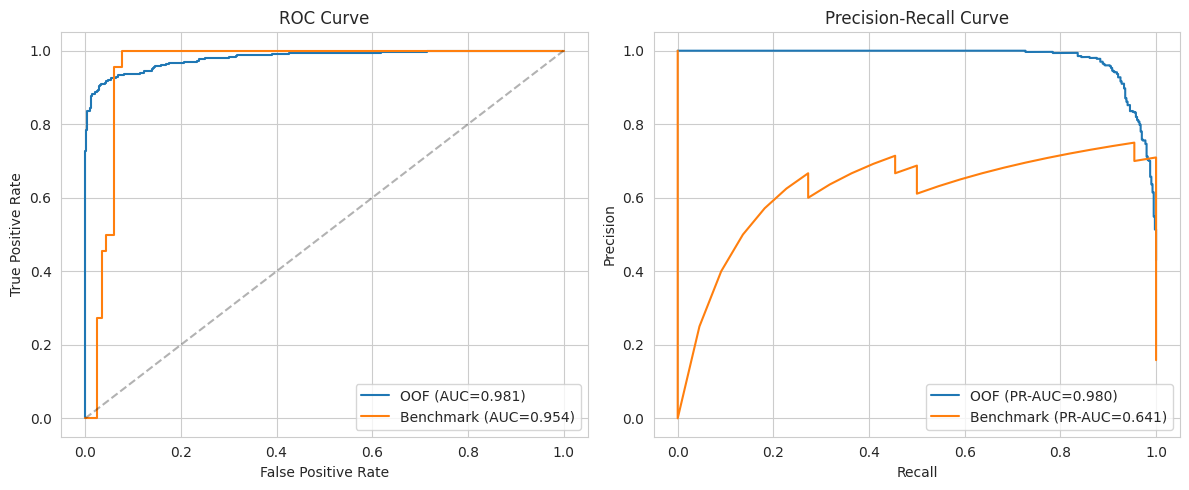

In [7]:
#@title # 8. ROC and Precision-Recall curves (OOF vs Benchmark)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr_oof, tpr_oof, _ = roc_curve(y_train_full, oof_proba)
fpr_bench, tpr_bench, _ = roc_curve(y_bench, y_bench_proba)
axes[0].plot(fpr_oof, tpr_oof, label=f"OOF (AUC={roc_auc_score(y_train_full, oof_proba):.3f})")
axes[0].plot(fpr_bench, tpr_bench, label=f"Benchmark (AUC={bench_metrics['auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

prec_oof, rec_oof, _ = precision_recall_curve(y_train_full, oof_proba)
prec_bench, rec_bench, _ = precision_recall_curve(y_bench, y_bench_proba)
axes[1].plot(rec_oof, prec_oof, label=f"OOF (PR-AUC={average_precision_score(y_train_full, oof_proba):.3f})")
axes[1].plot(rec_bench, prec_bench, label=f"Benchmark (PR-AUC={bench_metrics['pr_auc']:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "roc_pr_curves.png"), dpi=600)
plt.show()


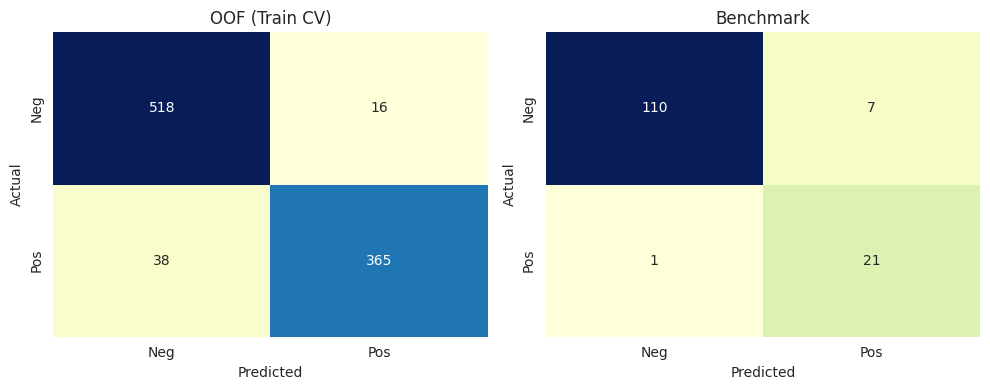

In [8]:
#@title # 9. Confusion matrix heatmaps (OOF vs Benchmark)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_oof = confusion_matrix(y_train_full, oof_pred)
cm_bench_ = confusion_matrix(y_bench, y_bench_pred)

for ax, cm, title in zip(axes, [cm_oof, cm_bench_], ["OOF (Train CV)", "Benchmark"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", cbar=False,
                xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "confusion_matrices.png"), dpi=600)
plt.show()


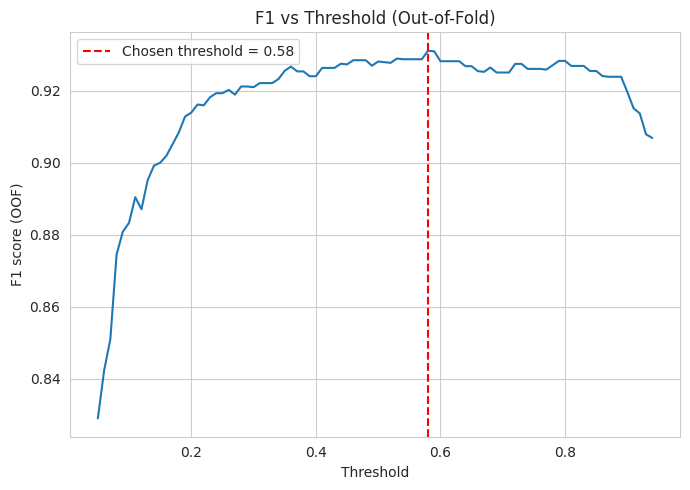

In [9]:
#@title # 10. F1 score vs threshold (OOF)
plt.figure(figsize=(7, 5))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, color="red", linestyle="--",
            label=f"Chosen threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1 score (OOF)")
plt.title("F1 vs Threshold (Out-of-Fold)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "f1_vs_threshold.png"), dpi=600)
plt.show()


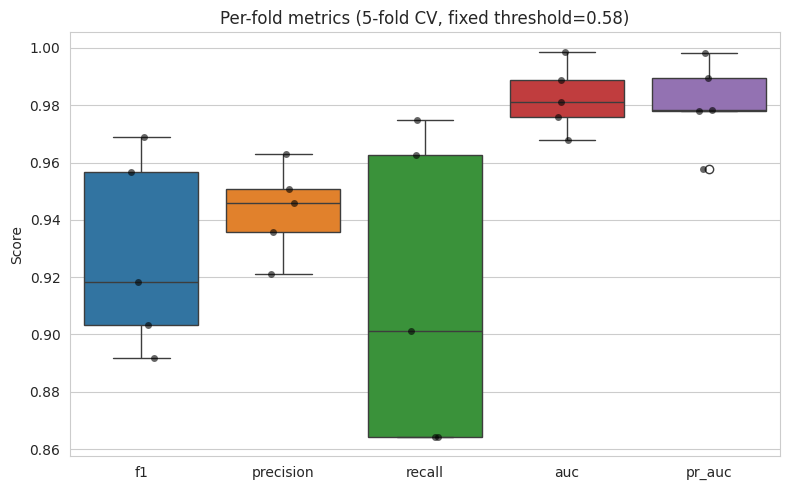

            f1  precision    recall      auc    pr_auc
mean  0.927730   0.943295  0.913426  0.98251  0.980405
std   0.033596   0.015787  0.052904  0.01186  0.015177


In [10]:
#@title # 11. Per-fold metrics with best hyperparameters (multi-metric)
# Same as Model #7: fold-level metrics were already captured during the
# OOF pass in section 5 to avoid a third expensive round of training --
# this cell only visualizes them.

plt.figure(figsize=(8, 5))
sns.boxplot(data=fold_metrics_df)
sns.stripplot(data=fold_metrics_df, color="black", size=5, alpha=0.6)
plt.ylabel("Score")
plt.title(f"Per-fold metrics ({N_FOLDS}-fold CV, fixed threshold={best_threshold:.2f})")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "cv_fold_metrics_boxplot.png"), dpi=600)
plt.show()

print(fold_metrics_df.describe().loc[["mean", "std"]])


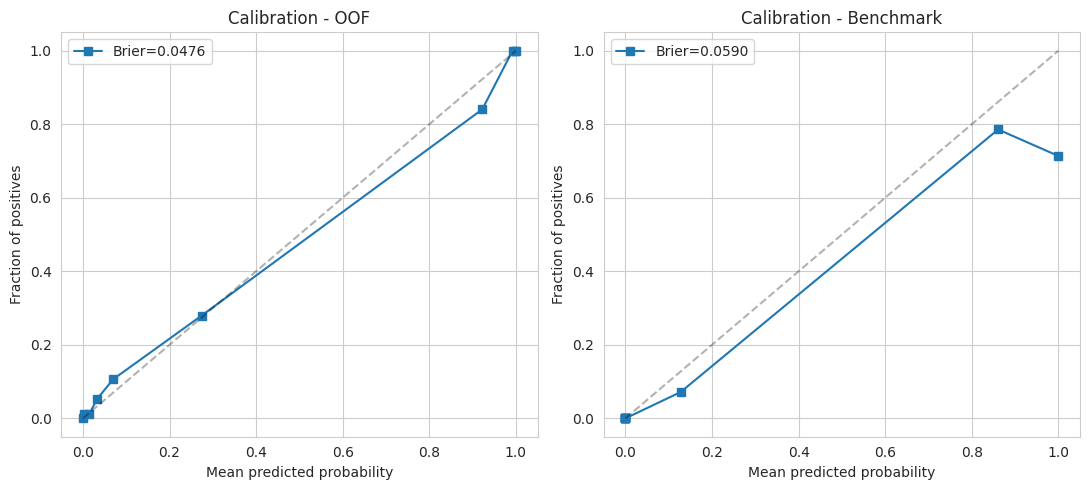

In [11]:
#@title # 12. Calibration curve & Brier score
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, proba, y_true, title in zip(
    axes, [oof_proba, y_bench_proba], [y_train_full, y_bench], ["OOF", "Benchmark"]
):
    frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "s-", label=f"Brier={brier_score_loss(y_true, proba):.4f}")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(f"Calibration - {title}")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "calibration_curves.png"), dpi=600)
plt.show()


False Positives: 7
                                   sequence  pred_proba  seq_len  n_missing_coords
MKFGKFVLLAASTALAVVGLGGPAAADSTPQAQPSIIGGS...    0.999997      238                 0
MTLTSTLRRQTRTTATATVLAAAAALALCAAPASAQQTGP...    1.000000      293                 0
MHLPRSRWDIPFKEETTMTHHFSVRALLAAGALLASAAVS...    0.980145      304                41
MFQRVWALTAALMLMLSLGATSSHAAQNPHERGPDPSNSY...    0.999615      284                25
MDSVMQTKEMVMKSNVNSYPIVLVHGFMGWGRNEVLGLKY...    0.965607      402                15
MGLAIAAAAVFSLPGVATATEPTGGVQPNIVGGGNATQVY...    1.000000      241                 0
MLVNGQHYHLTAAISGEKPALLMLHGFTGTSETFQDSISG...    0.924747      275                 0

False Negatives: 1
                                   sequence  pred_proba  seq_len  n_missing_coords
MVRVFGLTLLALLVPALAAPVPEDLEARQSGCADVMVVYA...    0.284363      203                 0


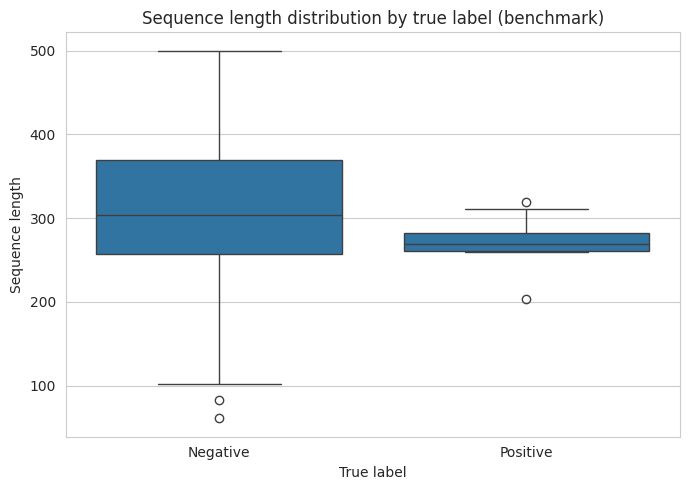

In [12]:
#@title # 13. Error analysis on the benchmark set
df_bench_result = pd.DataFrame({
    "id": bench_ids,
    "sequence": [artifacts[i]["sequence"] for i in bench_ids],
    "label": y_bench,
    "pred_proba": y_bench_proba,
    "pred_label": y_bench_pred,
    "n_missing_coords": [artifacts[i]["n_missing_coords"] for i in bench_ids],
})
df_bench_result["seq_len"] = df_bench_result["sequence"].str.len()

false_pos = df_bench_result[(df_bench_result["label"] == 0) & (df_bench_result["pred_label"] == 1)]
false_neg = df_bench_result[(df_bench_result["label"] == 1) & (df_bench_result["pred_label"] == 0)]

print(f"False Positives: {len(false_pos)}")
print(false_pos[["sequence", "pred_proba", "seq_len", "n_missing_coords"]].assign(
    sequence=lambda d: d["sequence"].str[:40] + "..."
).to_string(index=False))

print(f"\nFalse Negatives: {len(false_neg)}")
print(false_neg[["sequence", "pred_proba", "seq_len", "n_missing_coords"]].assign(
    sequence=lambda d: d["sequence"].str[:40] + "..."
).to_string(index=False))

df_bench_result.to_csv(os.path.join(MODEL_OUT_DIR, "benchmark_predictions_detailed.csv"), index=False)

plt.figure(figsize=(7, 5))
sns.boxplot(x="label", y="seq_len", data=df_bench_result)
plt.xticks([0, 1], ["Negative", "Positive"])
plt.xlabel("True label")
plt.ylabel("Sequence length")
plt.title("Sequence length distribution by true label (benchmark)")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "seq_len_by_label.png"), dpi=600)
plt.show()


In [13]:
#@title # 14. Bootstrap confidence intervals for benchmark metrics
# The benchmark set is small, so point estimates alone can be misleading.
# Bootstrap resampling gives a 95% CI for each metric.

def bootstrap_metric(y_true, values, metric_fn, n_boot=2000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    scores = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(metric_fn(y_true[idx], values[idx]))
    return np.mean(scores), np.percentile(scores, [2.5, 97.5])

metrics_to_bootstrap = {
    "f1": (f1_score, y_bench_pred),
    "precision": (precision_score, y_bench_pred),
    "recall": (recall_score, y_bench_pred),
    "auc": (roc_auc_score, y_bench_proba),
    "pr_auc": (average_precision_score, y_bench_proba),
}

print("Benchmark metrics with 95% bootstrap CI (n_boot=2000):")
ci_results = {}
for name, (fn, vals) in metrics_to_bootstrap.items():
    mean, (lo, hi) = bootstrap_metric(y_bench, vals, fn)
    ci_results[name] = {"mean": mean, "ci_low": lo, "ci_high": hi}
    print(f"  {name:<10}: {mean:.4f}  [{lo:.4f}, {hi:.4f}]")

pd.DataFrame(ci_results).T.to_csv(os.path.join(MODEL_OUT_DIR, "benchmark_metrics_bootstrap_ci.csv"))


Benchmark metrics with 95% bootstrap CI (n_boot=2000):
  f1        : 0.8380  [0.7143, 0.9362]
  precision : 0.7520  [0.5909, 0.9048]
  recall    : 0.9535  [0.8333, 1.0000]
  auc       : 0.9544  [0.9177, 0.9853]
  pr_auc    : 0.6692  [0.4796, 0.8850]


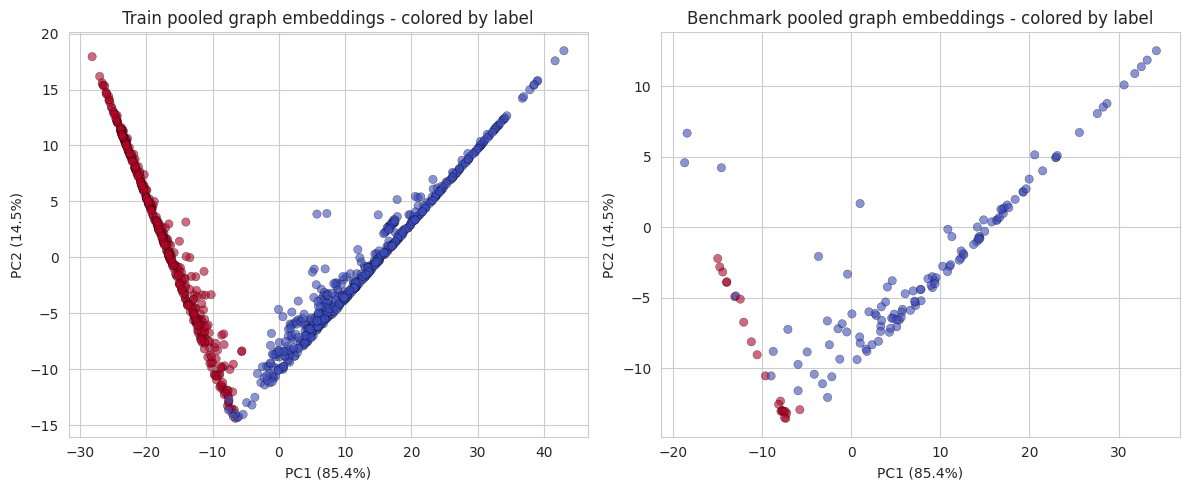

In [14]:
#@title # 15. PCA visualization of graph-level pooled embeddings
# Same as Model #7: PCA on the GNN's LEARNED graph-level embedding (output
# of the conv layers + mean pooling, before the final classifier head).
# Comparing this plot with Model #7's can hint at whether 3D structural
# information reshapes the learned representation.

@torch.no_grad()
def get_pooled_embeddings(model, ids, edge_key, batch_size=BATCH_SIZE):
    model.eval()
    loader = DataLoader(make_data_list(ids, edge_key), batch_size=batch_size, shuffle=False)
    embs = []
    for batch in loader:
        batch = batch.to(device)
        pooled = model.pool_embedding(batch.x, batch.edge_index, batch.batch)
        embs.append(pooled.cpu().numpy())
    return np.vstack(embs)

train_pooled = get_pooled_embeddings(final_model, train_ids_all, EDGE_KEY)
bench_pooled = get_pooled_embeddings(final_model, bench_ids, EDGE_KEY)

pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(train_pooled)
X_bench_pca = pca.transform(bench_pooled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, X_pca, y, title in zip(axes, [X_train_pca, X_bench_pca], [y_train_full, y_bench], ["Train", "Benchmark"]):
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.6, edgecolor="k", linewidth=0.3)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_title(f"{title} pooled graph embeddings - colored by label")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "embedding_pca.png"), dpi=600)
plt.show()


Additivity sanity check -- mean|gap|=1.4122, logit scale (std)=21.5298
shap_values_pos shape: (300, 64)


/tmp/ipykernel_1870/121915150.py:52: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_pos, train_pooled[sample_idx], show=False, max_display=20)


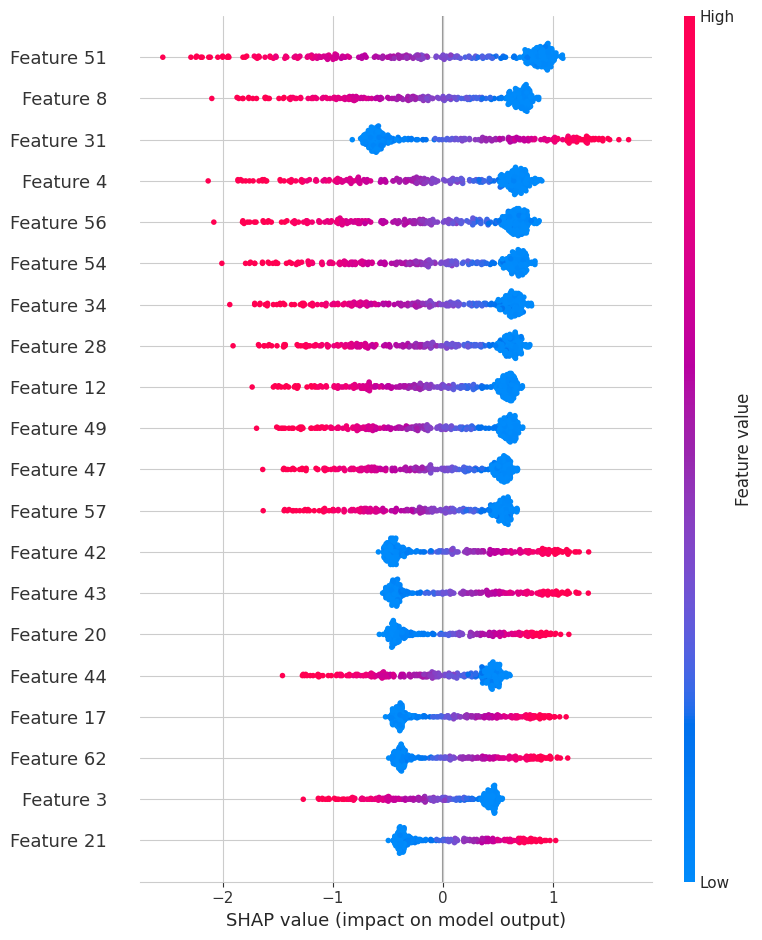

 pooled_embedding_dim  mean_abs_shap
                   51       0.851410
                    8       0.682995
                   31       0.678460
                    4       0.669805
                   56       0.664145
                   54       0.650451
                   34       0.617022
                   28       0.607686
                   12       0.567832
                   49       0.566559
                   47       0.529958
                   57       0.527251
                   42       0.511568
                   43       0.501400
                   20       0.464724
                   44       0.453353
                   17       0.446201
                   62       0.437532
                    3       0.418987
                   21       0.411142


In [15]:
#@title # 16. SHAP analysis - pooled-embedding level (model diagnostics)
# Same approach as Model #7: explain the classifier HEAD (fc1 -> ReLU ->
# fc2) with shap.GradientExplainer, treating the pooled graph embedding as
# tabular input. Diagnostic only (pooled dimensions are not individually
# human-readable) -- for biological interpretation, see the mutagenesis
# scan below.

class ClassifierHead(nn.Module):
    def __init__(self, gnn_model):
        super().__init__()
        self.fc1 = gnn_model.fc1
        self.fc2 = gnn_model.fc2

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))

head = ClassifierHead(final_model).to(device).eval()

background = torch.tensor(train_pooled[np.random.choice(len(train_pooled), min(100, len(train_pooled)), replace=False)],
                           dtype=torch.float32).to(device)

# GradientExplainer (expected-gradients) instead of DeepExplainer: it does
# not rely on layer-by-layer hooks matching every op in the graph exactly,
# so it is more robust for less-common architectures and does not carry
# DeepExplainer's strict additivity assertion (which can fail hard on
# some PyTorch graphs even when the underlying attributions are sound).
explainer = shap.GradientExplainer(head, background)

sample_idx = np.random.choice(len(train_pooled), min(300, len(train_pooled)), replace=False)
sample_input = torch.tensor(train_pooled[sample_idx], dtype=torch.float32).to(device)

try:
    shap_values = explainer.shap_values(sample_input, check_additivity=False)
except TypeError:
    shap_values = explainer.shap_values(sample_input)

shap_values_pos = shap_values[0] if isinstance(shap_values, list) else shap_values
shap_values_pos = np.asarray(shap_values_pos).reshape(len(sample_idx), -1)

# Sanity check: mean |sum(shap) - (f(x) - f(background))| should be small
# relative to the scale of the model's output logits.
with torch.no_grad():
    f_x = head(sample_input).cpu().numpy().reshape(-1)
    f_base = head(background).cpu().numpy().mean()
shap_sum = shap_values_pos.sum(axis=1)
gap = np.abs(shap_sum - (f_x - f_base))
print(f"Additivity sanity check -- mean|gap|={gap.mean():.4f}, logit scale (std)={f_x.std():.4f}")

print(f"shap_values_pos shape: {shap_values_pos.shape}")

plt.figure()
shap.summary_plot(shap_values_pos, train_pooled[sample_idx], show=False, max_display=20)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "shap_summary_pooled_embedding.png"), dpi=600, bbox_inches="tight")
plt.show()

mean_abs_shap = np.abs(shap_values_pos).mean(axis=0)
top_dims = np.argsort(mean_abs_shap)[::-1][:20]

importance_df = pd.DataFrame({
    "pooled_embedding_dim": top_dims,
    "mean_abs_shap": mean_abs_shap[top_dims],
})
print(importance_df.to_string(index=False))
importance_df.to_csv(os.path.join(MODEL_OUT_DIR, "shap_top_embedding_dims.csv"), index=False)


Fetching IsPETase (A0A0K8P6T7) sequence from UniProt...
  Length: 290 aa
  Fetching IsPETase 3D structure (PDB 5XJH) from RCSB...
  Resolved CA coordinates for 261/290 residues (29 unresolved -- chain-fallback edges used there).
  Base predicted probability: 0.9995
  Known catalytic triad: [160, 206, 237]
    position 160: rank 242/290 (top 83.4%), delta=-0.00010
    position 206: rank 203/290 (top 70.0%), delta=-0.00001
    position 237: rank 39/290 (top 13.4%), delta=0.00026
  Top-15 predicted important positions: [5, 54, 63, 136, 141, 142, 159, 174, 192, 193, 195, 213, 217, 257, 270]
  Overlap with catalytic triad (top-15): [] (0/3)
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model8_1d3d_graph_contact/reference_mutagenesis_ispetase_full_scan.xlsx
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model8_1d3d_graph_contact/reference_mutagenesis_ispetase_full_scan.csv

  Alanine substitution vs native <mask> substitution (

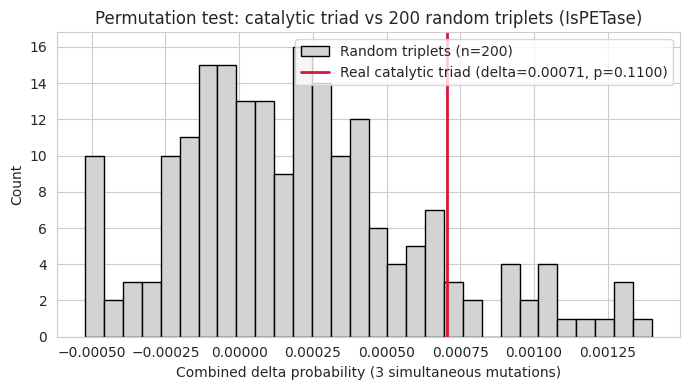


  Running windowed mutagenesis scan (window_size=7)... this runs ~290 more forward passes, so it takes a bit.
  Window-centered rank of catalytic positions (window_size=7):
    position 160: window-rank 87/290 (top 30.0%), window_delta=0.00090 (vs single-residue delta=-0.00010)
    position 206: window-rank 199/290 (top 68.6%), window_delta=-0.00000 (vs single-residue delta=-0.00001)
    position 237: window-rank 103/290 (top 35.5%), window_delta=0.00072 (vs single-residue delta=0.00026)


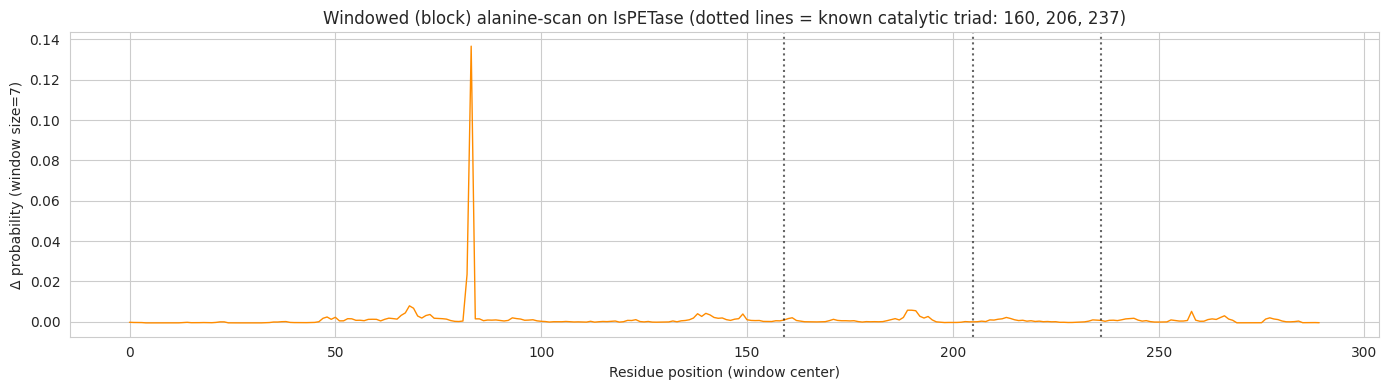

  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model8_1d3d_graph_contact/reference_mutagenesis_ispetase_windowed_scan.xlsx
  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model8_1d3d_graph_contact/reference_mutagenesis_ispetase_windowed_scan.csv


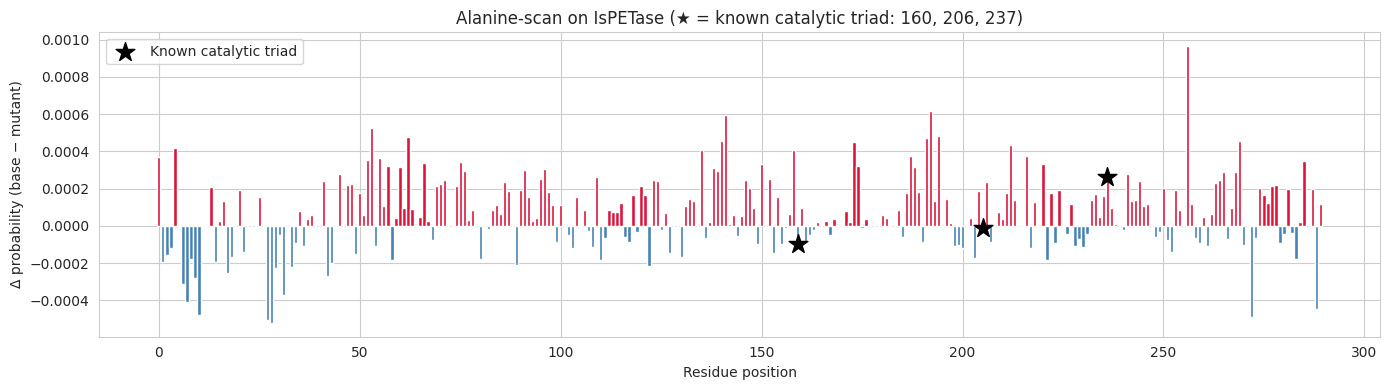

Fetching LCC (G9BY57) sequence from UniProt...
  Length: 293 aa
  Fetching LCC 3D structure (PDB 4EB0) from RCSB...
  Resolved CA coordinates for 258/293 residues (35 unresolved -- chain-fallback edges used there).
  Base predicted probability: 1.0000
  Known catalytic triad: [165, 210, 242]
    position 165: rank 145/293 (top 49.5%), delta=0.00000
    position 210: rank 242/293 (top 82.6%), delta=-0.00000
    position 242: rank 199/293 (top 67.9%), delta=-0.00000
  Top-15 predicted important positions: [3, 6, 7, 26, 30, 38, 143, 144, 179, 229, 259, 268, 272, 280, 291]
  Overlap with catalytic triad (top-15): [] (0/3)
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model8_1d3d_graph_contact/reference_mutagenesis_lcc_full_scan.xlsx
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model8_1d3d_graph_contact/reference_mutagenesis_lcc_full_scan.csv

  Alanine substitution vs native <mask> substitution (catalytic triad only):
 posi

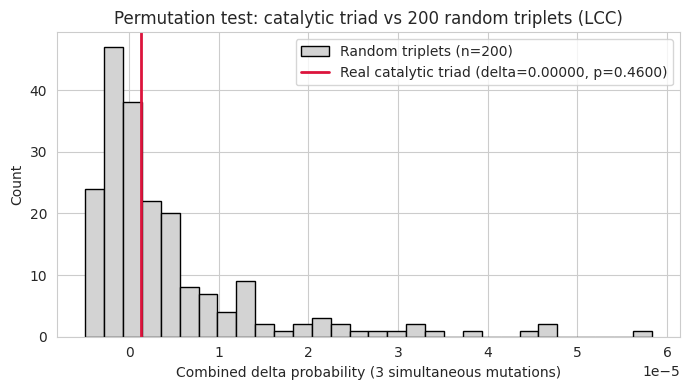


  Running windowed mutagenesis scan (window_size=7)... this runs ~293 more forward passes, so it takes a bit.
  Window-centered rank of catalytic positions (window_size=7):
    position 165: window-rank 250/293 (top 85.3%), window_delta=-0.00000 (vs single-residue delta=0.00000)
    position 210: window-rank 197/293 (top 67.2%), window_delta=-0.00000 (vs single-residue delta=-0.00000)
    position 242: window-rank 191/293 (top 65.2%), window_delta=-0.00000 (vs single-residue delta=-0.00000)


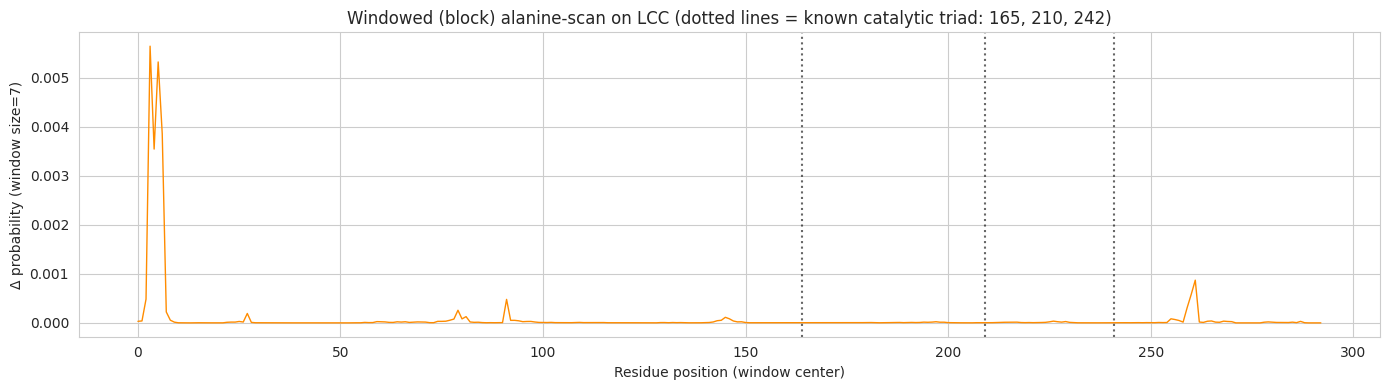

  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model8_1d3d_graph_contact/reference_mutagenesis_lcc_windowed_scan.xlsx
  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model8_1d3d_graph_contact/reference_mutagenesis_lcc_windowed_scan.csv


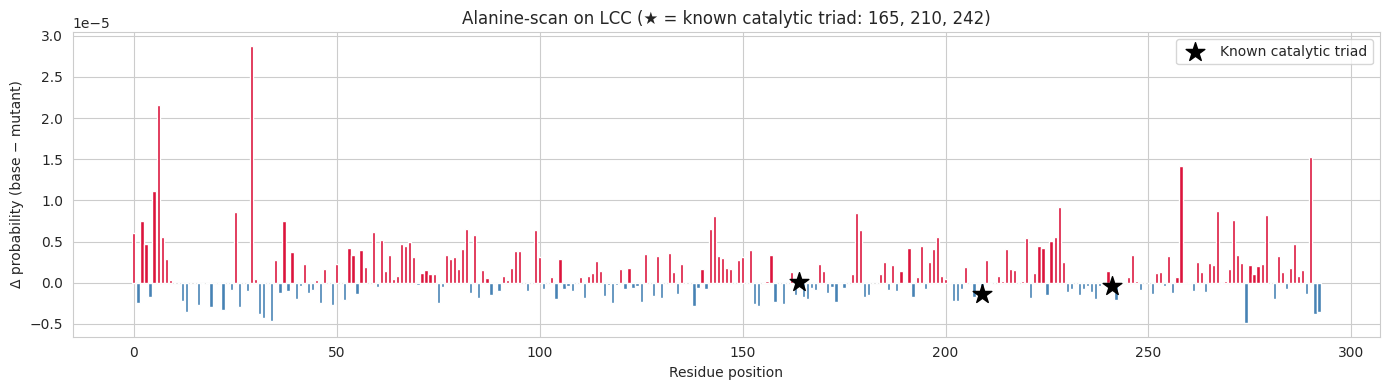

Fetching CalB_negative_control (P41365) sequence from UniProt...
  Length: 342 aa
  Fetching CalB_negative_control 3D structure (PDB 1TCA) from RCSB...
  Resolved CA coordinates for 317/342 residues (25 unresolved -- chain-fallback edges used there).
  Base predicted probability: 0.9885
  Known catalytic triad: [130, 212, 249]
    position 130: rank 15/342 (top 4.4%), delta=0.00888
    position 212: rank 85/342 (top 24.9%), delta=0.00411
    position 249: rank 1/342 (top 0.3%), delta=0.02488
  Top-15 predicted important positions: [90, 91, 107, 113, 118, 120, 122, 130, 148, 208, 249, 295, 303, 305, 310]
  Overlap with catalytic triad (top-15): [130, 249] (2/3)
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model8_1d3d_graph_contact/reference_mutagenesis_calb_negative_control_full_scan.xlsx
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model8_1d3d_graph_contact/reference_mutagenesis_calb_negative_control_full_scan.csv

  A

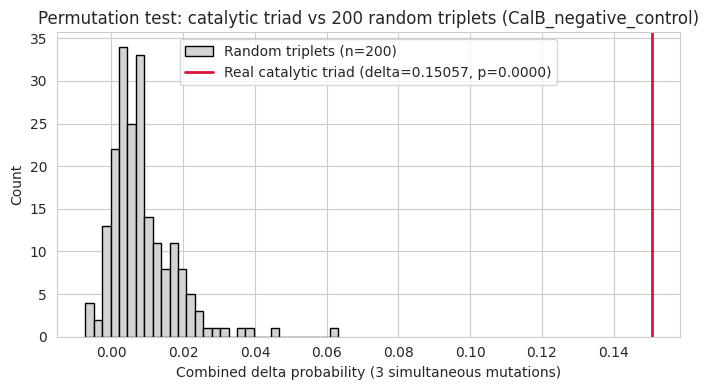


  Running windowed mutagenesis scan (window_size=7)... this runs ~342 more forward passes, so it takes a bit.
  Window-centered rank of catalytic positions (window_size=7):
    position 130: window-rank 15/342 (top 4.4%), window_delta=0.61311 (vs single-residue delta=0.00888)
    position 212: window-rank 104/342 (top 30.4%), window_delta=0.10545 (vs single-residue delta=0.00411)
    position 249: window-rank 178/342 (top 52.0%), window_delta=0.05391 (vs single-residue delta=0.02488)


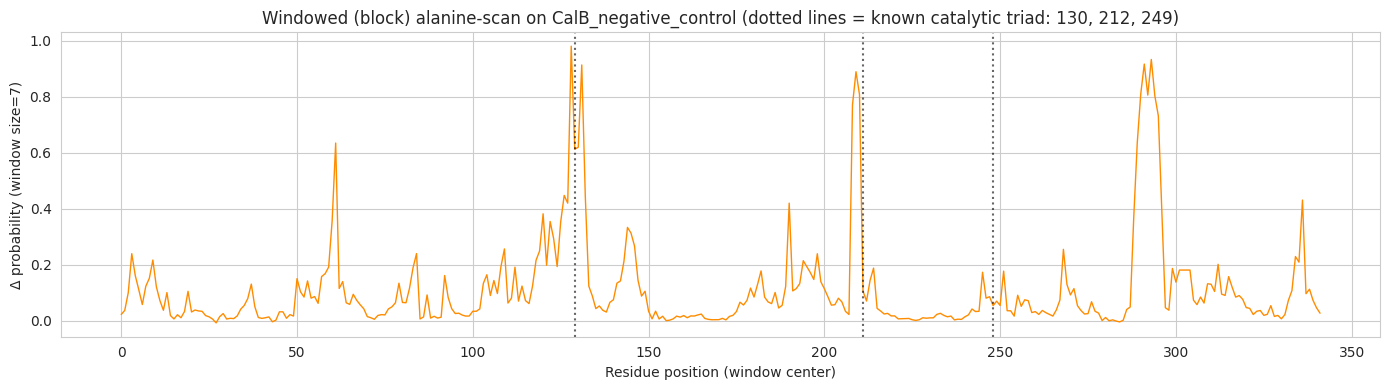

  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model8_1d3d_graph_contact/reference_mutagenesis_calb_negative_control_windowed_scan.xlsx
  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model8_1d3d_graph_contact/reference_mutagenesis_calb_negative_control_windowed_scan.csv


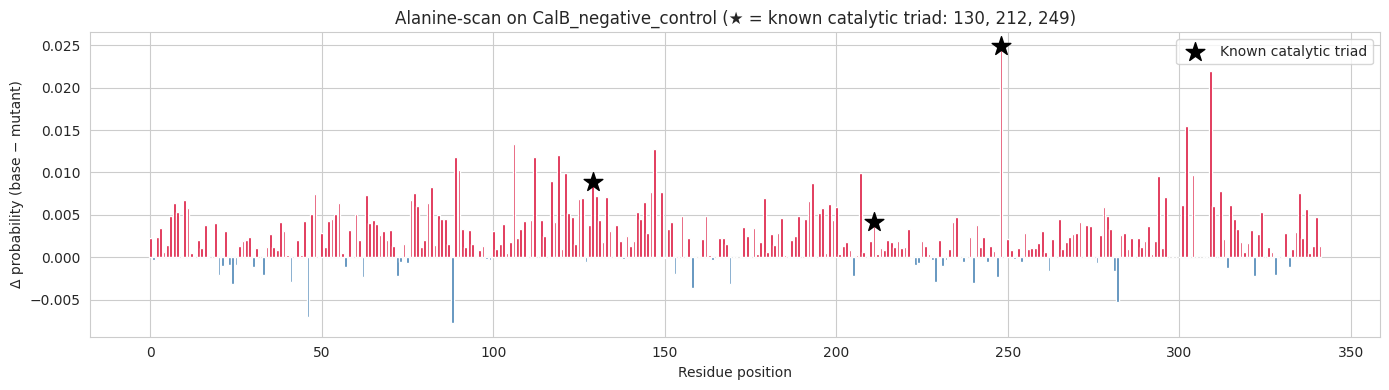


Saved reference scan results to /content/drive/MyDrive/InterPET/models/model8_1d3d_graph_contact/reference_mutagenesis_results.pkl

Tip: compare this reference-scan output with Model #7's for the SAME
IsPETase sequence to see whether adding real 3D contact edges shifts
which residues the model considers most important around the active site.


In [9]:
#@title # 17. Fixed reference-sequence scan -- IsPETase active site (valid cross-model comparison)
# Mirrors Model #1/#7's section 17: scan a FIXED reference sequence, chosen
# independently of any model's predictions, with a catalytic site already
# confirmed in the literature: IsPETase (Ideonella sakaiensis PETase),
# UniProt A0A0K8P6T7, crystal structure PDB 5XJH.
#
#   Catalytic triad: Ser160, Asp206, His237
#   (Yoshida et al. 2016, Science; Han et al. 2017, Nat. Commun., PDB 5XJH --
#   confirmed structurally and by site-directed mutagenesis; any substitution
#   at these positions abolishes catalytic activity.)
#
# Because every model notebook scans this exact same sequence, the top
# residues each model highlights can be directly compared, and checked
# against a real, experimentally-confirmed active site -- not just against
# each other.
#
# MODEL #8-SPECIFIC DIFFERENCE vs Model #7: this model's edges come from a
# real 3D contact map, so scanning a fixed reference sequence here ALSO
# requires that reference's own 3D structure (not just its sequence) --
# unlike Model #7's chain edges, which only need sequence length. We
# therefore fetch the actual PDB 5XJH structure and build CA-CA contact
# edges from it, exactly as done for the training set in section 3. Per
# the same SIMPLIFYING ASSUMPTION used throughout this notebook, those
# contact edges are held FIXED across all mutations below -- only the
# ESM-2 node features change to reflect each substituted residue.

!pip install -q biopython openpyxl
import requests
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1
from Bio.Align import PairwiseAligner
import warnings
from Bio import BiopythonWarning
warnings.simplefilter("ignore", BiopythonWarning)

# Self-contained alignment helpers (re-declared here, independent of
# whatever ran earlier this session) so this cell works whether section 3
# actually ran, or the "[OPTIONAL] Resume from checkpoint" cell was used
# instead (which does not redefine the PDB-parsing/alignment machinery,
# since it is only needed once, to build the ORIGINAL training artifacts).
_ref_pdb_parser = PDBParser(QUIET=True)
_ref_aligner = PairwiseAligner()
_ref_aligner.mode = "global"
_ref_aligner.open_gap_score = -10
_ref_aligner.extend_gap_score = -0.5
_ref_aligner.match_score = 2
_ref_aligner.mismatch_score = -1


def _extract_chain_ca_ref(chain):
    residues, coords = [], []
    for res in chain:
        if res.id[0] != " ":  # skip HETATM/water
            continue
        try:
            aa = seq1(res.get_resname())
        except Exception:
            aa = "X"
        if aa in ("", "X"):
            continue
        residues.append(aa)
        coords.append(res["CA"].get_coord() if "CA" in res else None)
    return "".join(residues), coords


def get_ca_coords_for_reference(pdb_path, target_sequence):
    """Same alignment-based CA-extraction logic used to build the training
    graphs in section 3 -- finds the best-matching chain in the PDB file
    and returns a (len(target_sequence), 3) array of CA coordinates
    (np.nan for unresolved/missing positions)."""
    structure = _ref_pdb_parser.get_structure("ref", pdb_path)
    best_score, best_chain_seq, best_chain_coords = -1e9, None, None
    for model in structure:
        for chain in model:
            chain_seq, chain_coords = _extract_chain_ca_ref(chain)
            if len(chain_seq) < 10:
                continue
            try:
                score = _ref_aligner.score(target_sequence, chain_seq)
            except Exception:
                continue
            if score > best_score:
                best_score = score
                best_chain_seq, best_chain_coords = chain_seq, chain_coords
        break  # only the first model
    if best_chain_seq is None:
        return None

    alignment = _ref_aligner.align(target_sequence, best_chain_seq)[0]
    coord_array = np.full((len(target_sequence), 3), np.nan, dtype=np.float32)
    target_aligned, chain_aligned = alignment[0], alignment[1]
    ti = ci = 0
    for t_char, c_char in zip(target_aligned, chain_aligned):
        if t_char != "-" and c_char != "-":
            coord = best_chain_coords[ci] if ci < len(best_chain_coords) else None
            if coord is not None:
                coord_array[ti] = coord
        if t_char != "-":
            ti += 1
        if c_char != "-":
            ci += 1
    return coord_array


def fetch_uniprot_sequence(uniprot_id):
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    lines = resp.text.strip().split("\n")
    return "".join(lines[1:])  # drop the ">header" line


def fetch_rcsb_structure(pdb_id, save_dir):
    os.makedirs(save_dir, exist_ok=True)
    path = os.path.join(save_dir, f"{pdb_id}.pdb")
    if not os.path.exists(path):
        url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        with open(path, "wb") as f:
            f.write(resp.content)
    return path


@torch.no_grad()
def build_graph_for_sequence(sequence, coord_array, L):
    """Rebuild the node embeddings for `sequence` (ESM-2 per-residue), but
    REUSE the fixed contact-map edges built from `coord_array` (see the
    simplifying assumption in the module docstring above)."""
    node_emb, seq_used = get_per_residue_embedding(sequence)
    edge_index_contact, _ = build_contact_edges(coord_array, L)
    return Data(x=node_emb, edge_index=edge_index_contact), seq_used


@torch.no_grad()
def predict_single(model, data):
    data = data.to(device)
    batch = torch.zeros(data.x.shape[0], dtype=torch.long, device=device)
    logit = model(data.x, data.edge_index, batch)
    return float(1 / (1 + np.exp(-logit.item())))


def mutagenesis_scan(sequence, coord_array, model, mutate_to="A"):
    """Return (base_proba, per_position_deltas) for a single sequence,
    reusing the ORIGINAL contact-map edges for every mutant."""
    seq = sequence.strip().upper()
    L = len(seq)
    base_data, seq_used = build_graph_for_sequence(seq, coord_array, L)
    base_proba = predict_single(model, base_data)

    deltas = np.zeros(len(seq_used))
    for i, aa in enumerate(seq_used):
        if aa == mutate_to:
            deltas[i] = 0.0
            continue
        mutant_seq = seq_used[:i] + mutate_to + seq_used[i + 1:]
        mutant_data, _ = build_graph_for_sequence(mutant_seq, coord_array, L)
        mutant_proba = predict_single(model, mutant_data)
        deltas[i] = base_proba - mutant_proba

    return base_proba, deltas


def windowed_mutagenesis_scan(sequence, coord_array, model, window_size=7, mutate_to="A"):
    """Slide a contiguous window across the sequence, mutating the WHOLE
    window to alanine at once (rather than one residue at a time), and
    record the resulting delta at the window's center position. Contact
    edges are reused unchanged (same simplifying assumption)."""
    seq = sequence.strip().upper()
    n = len(seq)
    half = window_size // 2

    base_data, seq_used = build_graph_for_sequence(seq, coord_array, n)
    base_proba = predict_single(model, base_data)

    window_deltas = np.zeros(n)
    for center in range(n):
        start = max(0, center - half)
        end = min(n, center + half + 1)
        mutant_seq = seq[:start] + mutate_to * (end - start) + seq[end:]
        mutant_data, _ = build_graph_for_sequence(mutant_seq, coord_array, n)
        mutant_proba = predict_single(model, mutant_data)
        window_deltas[center] = base_proba - mutant_proba

    return base_proba, window_deltas


@torch.no_grad()
def predict_with_masked_position(sequence, pos_1indexed, coord_array, model, max_len=MAX_SEQ_LEN):
    """Like predict_single, but the residue at `pos_1indexed` is replaced
    with ESM-2's native <mask> token BEFORE embedding (instead of the
    literal alanine substitution used everywhere else in this section).
    Contact edges are reused unchanged."""
    seq = sequence[:max_len]
    inputs = esm2_tokenizer([seq], return_tensors="pt", truncation=True, max_length=max_len + 2)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    masked_ids = inputs["input_ids"].clone()
    masked_ids[0, pos_1indexed] = esm2_tokenizer.mask_token_id  # index 0 is <cls>, so residue `pos` sits at token index `pos`
    out = esm2_model(input_ids=masked_ids, attention_mask=inputs["attention_mask"])
    hidden = out.last_hidden_state[0]
    residue_emb = hidden[1:1 + len(seq)].cpu()

    edge_index_contact, _ = build_contact_edges(coord_array, len(seq))
    data = Data(x=residue_emb, edge_index=edge_index_contact)
    return predict_single(model, data)


REFERENCE_SEQUENCES = {
    "IsPETase": {
        "uniprot_id": "A0A0K8P6T7",
        "pdb_id": "5XJH",
        "source": "Yoshida et al. 2016 Science; Han et al. 2017 Nat Commun (PDB 5XJH)",
        "catalytic_triad_positions": [160, 206, 237],  # Ser160, Asp206, His237 (1-indexed)
        "expected_residues": {160: "S", 206: "D", 237: "H"},
        "is_petase": True,
    },
    "LCC": {
        "uniprot_id": "G9BY57",
        "pdb_id": "4EB0",
        "source": "Sulaiman et al. 2012 Appl Environ Microbiol; Tournier et al. 2020 Nature (PDB 4EB0)",
        "catalytic_triad_positions": [165, 210, 242],  # Ser165, Asp210, His242 (1-indexed)
        "expected_residues": {165: "S", 210: "D", 242: "H"},
        "is_petase": True,
    },
    "CalB_negative_control": {
        "uniprot_id": "P41365",
        "pdb_id": "1TCA",
        "source": "Uppenberg et al. 1994 Structure (PDB 1TCA) -- Candida antarctica Lipase B, "
                   "NOT PET-active; same catalytic mechanism/fold family as PETases, used as "
                   "a functional-specificity negative control",
        "catalytic_triad_positions": [130, 212, 249],  # Ser130, Asp212, His249 (1-indexed)
        "expected_residues": {130: "S", 212: "D", 249: "H"},
        "is_petase": False,
    },
}


reference_scan_results = {}

for ref_name, ref_info in REFERENCE_SEQUENCES.items():
    print(f"Fetching {ref_name} ({ref_info['uniprot_id']}) sequence from UniProt...")
    ref_seq = fetch_uniprot_sequence(ref_info["uniprot_id"])
    print(f"  Length: {len(ref_seq)} aa")

    print(f"  Fetching {ref_name} 3D structure (PDB {ref_info['pdb_id']}) from RCSB...")
    ref_pdb_dir = os.path.join(MODEL_OUT_DIR, "reference_structures")
    ref_pdb_path = fetch_rcsb_structure(ref_info["pdb_id"], ref_pdb_dir)

    ref_coord_array = get_ca_coords_for_reference(ref_pdb_path, ref_seq)
    if ref_coord_array is None:
        print(f"  [WARN] Could not align {ref_name} sequence to its structure -- skipping this reference.")
        continue

    ref_L = len(ref_seq)
    n_resolved = int((~np.isnan(ref_coord_array).any(axis=1)).sum())
    print(f"  Resolved CA coordinates for {n_resolved}/{ref_L} residues "
          f"({ref_L - n_resolved} unresolved -- chain-fallback edges used there).")

    base_p, deltas = mutagenesis_scan(ref_seq, ref_coord_array, final_model)
    print(f"  Base predicted probability: {base_p:.4f}")

    top_n = 15
    order = np.argsort(deltas)[::-1]
    top_positions = set((order[:top_n] + 1).tolist())  # 1-indexed
    known_positions = set(ref_info["catalytic_triad_positions"])
    overlap = known_positions & top_positions

    rank_of = {pos: int(np.where(order == (pos - 1))[0][0]) + 1 for pos in known_positions}
    n_total = len(deltas)
    print(f"  Known catalytic triad: {sorted(known_positions)}")
    for pos in sorted(known_positions):
        pct_from_top = 100 * rank_of[pos] / n_total
        print(f"    position {pos}: rank {rank_of[pos]}/{n_total} (top {pct_from_top:.1f}%), delta={deltas[pos-1]:.5f}")
    print(f"  Top-{top_n} predicted important positions: {sorted(top_positions)}")
    print(f"  Overlap with catalytic triad (top-{top_n}): {sorted(overlap)} ({len(overlap)}/{len(known_positions)})")

    # ---- Export full per-residue delta table to Excel + CSV ----
    full_scan_df = pd.DataFrame({
        "position": np.arange(1, ref_L + 1),
        "residue": list(ref_seq),
        "delta_proba": deltas,
        "has_resolved_coord": ~np.isnan(ref_coord_array).any(axis=1),
        "is_known_catalytic_residue": [p in known_positions for p in range(1, ref_L + 1)],
    }).sort_values("delta_proba", ascending=False).reset_index(drop=True)

    excel_path = os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_full_scan.xlsx")
    csv_path = os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_full_scan.csv")
    full_scan_df.to_excel(excel_path, index=False, sheet_name="alanine_scan")
    full_scan_df.to_csv(csv_path, index=False)
    print(f"  Saved full per-residue delta table to {excel_path}")
    print(f"  Saved full per-residue delta table to {csv_path}")

    # ---- Variation 1: mask-token substitution vs alanine, at the 3 known positions only ----
    mask_comparison = []
    for pos in sorted(known_positions):
        mask_proba = predict_with_masked_position(ref_seq, pos, ref_coord_array, final_model)
        mask_delta = base_p - mask_proba
        mask_comparison.append({
            "position": pos,
            "residue": ref_seq[pos - 1],
            "alanine_delta": deltas[pos - 1],
            "mask_delta": mask_delta,
        })

    mask_comparison_df = pd.DataFrame(mask_comparison)
    print("\n  Alanine substitution vs native <mask> substitution (catalytic triad only):")
    print(mask_comparison_df.to_string(index=False))

    # ---- Variation 2: combined (simultaneous) triple mutation vs sum of individual deltas ----
    seq_list = list(ref_seq)
    for pos in known_positions:
        seq_list[pos - 1] = "A"
    combined_mutant_seq = "".join(seq_list)
    combined_data, _ = build_graph_for_sequence(combined_mutant_seq, ref_coord_array, ref_L)
    combined_proba = predict_single(final_model, combined_data)
    combined_delta = base_p - combined_proba
    sum_individual_deltas = sum(deltas[pos - 1] for pos in known_positions)

    print(f"\n  Combined triple-mutation (all 3 catalytic residues -> Ala simultaneously):")
    print(f"    proba after combined mutation : {combined_proba:.4f}")
    print(f"    combined delta                : {combined_delta:.5f}")
    print(f"    sum of individual deltas       : {sum_individual_deltas:.5f}")
    print(f"    synergy (combined - sum)        : {combined_delta - sum_individual_deltas:.5f}")

    # ---- Variation 2b: permutation test for the combined-mutation synergy ----
    # Is the combined delta actually special, or would mutating ANY random
    # triplet of positions simultaneously tend to produce a similarly large
    # delta (since disturbing 3 positions at once is inherently a bigger
    # perturbation than disturbing 1)? We build a null distribution from
    # random triplets (excluding the real triad) and see where the real
    # triad's combined delta falls within it.
    n_permutations = 200
    rng = np.random.default_rng(RANDOM_SEED)
    all_positions = np.arange(1, ref_L + 1)
    candidate_positions = np.setdiff1d(all_positions, list(known_positions))

    null_deltas = np.zeros(n_permutations)
    for p_i in range(n_permutations):
        rand_positions = rng.choice(candidate_positions, size=len(known_positions), replace=False)
        seq_list_rand = list(ref_seq)
        for pos in rand_positions:
            seq_list_rand[pos - 1] = "A"
        rand_mutant_seq = "".join(seq_list_rand)
        rand_data, _ = build_graph_for_sequence(rand_mutant_seq, ref_coord_array, ref_L)
        rand_proba = predict_single(final_model, rand_data)
        null_deltas[p_i] = base_p - rand_proba
        if (p_i + 1) % 50 == 0:
            print(f"    permutation {p_i + 1}/{n_permutations}...")

    p_value = float(np.mean(null_deltas >= combined_delta))
    z_score = float((combined_delta - null_deltas.mean()) / (null_deltas.std() + 1e-12))

    print(f"\n  Permutation test (n={n_permutations} random triplets of positions, "
          f"excluding the real catalytic triad):")
    print(f"    null distribution -- mean={null_deltas.mean():.5f}, std={null_deltas.std():.5f}, "
          f"max={null_deltas.max():.5f}")
    print(f"    observed combined delta (real catalytic triad): {combined_delta:.5f}")
    print(f"    empirical p-value (P[null >= observed]): {p_value:.4f}")
    print(f"    z-score: {z_score:.3f}")

    plt.figure(figsize=(7, 4))
    plt.hist(null_deltas, bins=30, color="lightgray", edgecolor="black", label=f"Random triplets (n={n_permutations})")
    plt.axvline(combined_delta, color="crimson", linewidth=2,
                label=f"Real catalytic triad (delta={combined_delta:.5f}, p={p_value:.4f})")
    plt.xlabel("Combined delta probability (3 simultaneous mutations)")
    plt.ylabel("Count")
    plt.title(f"Permutation test: catalytic triad vs {n_permutations} random triplets ({ref_name})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_permutation_test.png"), dpi=600)
    plt.show()

    pd.DataFrame({"null_delta": null_deltas}).to_csv(
        os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_permutation_null.csv"), index=False
    )

    # ---- Variation 3: windowed/block mutagenesis ----
    window_size = 7
    print(f"\n  Running windowed mutagenesis scan (window_size={window_size})... "
          f"this runs ~{ref_L} more forward passes, so it takes a bit.")
    _, window_deltas = windowed_mutagenesis_scan(ref_seq, ref_coord_array, final_model, window_size=window_size)

    window_order = np.argsort(window_deltas)[::-1]
    print(f"  Window-centered rank of catalytic positions (window_size={window_size}):")
    for pos in sorted(known_positions):
        w_rank = int(np.where(window_order == (pos - 1))[0][0]) + 1
        w_pct = 100 * w_rank / n_total
        print(f"    position {pos}: window-rank {w_rank}/{n_total} (top {w_pct:.1f}%), "
              f"window_delta={window_deltas[pos-1]:.5f} (vs single-residue delta={deltas[pos-1]:.5f})")

    plt.figure(figsize=(14, 4))
    plt.plot(range(len(window_deltas)), window_deltas, color="darkorange", linewidth=1)
    for pos in known_positions:
        plt.axvline(pos - 1, color="black", linestyle=":", alpha=0.6)
    plt.xlabel("Residue position (window center)")
    plt.ylabel(f"Δ probability (window size={window_size})")
    plt.title(f"Windowed (block) alanine-scan on {ref_name} "
              f"(dotted lines = known catalytic triad: {', '.join(str(p) for p in sorted(known_positions))})")
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_windowed.png"), dpi=600)
    plt.show()

    window_scan_df = pd.DataFrame({
        "position": np.arange(1, ref_L + 1),
        "residue": list(ref_seq),
        "window_delta_proba": window_deltas,
        "single_residue_delta_proba": deltas,
        "has_resolved_coord": ~np.isnan(ref_coord_array).any(axis=1),
        "is_known_catalytic_residue": [p in known_positions for p in range(1, ref_L + 1)],
    }).sort_values("window_delta_proba", ascending=False).reset_index(drop=True)
    window_excel_path = os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_windowed_scan.xlsx")
    window_csv_path = os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_windowed_scan.csv")
    window_scan_df.to_excel(window_excel_path, index=False, sheet_name=f"window{window_size}_scan")
    window_scan_df.to_csv(window_csv_path, index=False)
    print(f"  Saved windowed scan table to {window_excel_path}")
    print(f"  Saved windowed scan table to {window_csv_path}")

    reference_scan_results[ref_name] = {
        "sequence": ref_seq,
        "pdb_id": ref_info["pdb_id"],
        "coord_array": ref_coord_array,
        "n_resolved_coords": n_resolved,
        "base_proba": base_p,
        "deltas": deltas,
        "window_deltas": window_deltas,
        "window_size": window_size,
        "top_positions": sorted(top_positions),
        "known_catalytic_triad": sorted(known_positions),
        "overlap_with_catalytic_triad": sorted(overlap),
        "rank_of_known_positions": rank_of,
        "mask_vs_alanine_comparison": mask_comparison,
        "combined_triple_mutation_delta": combined_delta,
        "sum_of_individual_deltas": sum_individual_deltas,
        "permutation_test_null_deltas": null_deltas,
        "permutation_test_p_value": p_value,
        "permutation_test_z_score": z_score,
    }

    plt.figure(figsize=(14, 4))
    colors = ["crimson" if d > 0 else "steelblue" for d in deltas]
    plt.bar(range(len(deltas)), deltas, color=colors)
    for pos in known_positions:
        plt.scatter([pos - 1], [deltas[pos - 1]], marker="*", s=200,
                    color="black", zorder=5,
                    label="Known catalytic triad" if pos == min(known_positions) else None)
    plt.xlabel("Residue position")
    plt.ylabel("Δ probability (base − mutant)")
    plt.title(f"Alanine-scan on {ref_name} (★ = known catalytic triad: "
              f"{', '.join(str(p) for p in sorted(known_positions))})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}.png"), dpi=600)
    plt.show()

with open(os.path.join(MODEL_OUT_DIR, "reference_mutagenesis_results.pkl"), "wb") as f:
    pickle.dump(reference_scan_results, f)

print(f"\nSaved reference scan results to {MODEL_OUT_DIR}/reference_mutagenesis_results.pkl")
print("\nTip: compare this reference-scan output with Model #7's for the SAME")
print("IsPETase sequence to see whether adding real 3D contact edges shifts")
print("which residues the model considers most important around the active site.")


In [ ]:
#@title # 18. Top-15 residues for the top-3 highest-confidence benchmark sequences
# Mirrors Model #1/#7's section 18. Selection criterion here is purely the
# model's own predicted probability (base_proba on the benchmark set) --
# the 3 sequences the model is most confident about, regardless of
# TP/FP/FN status. mutagenesis_scan() and build_graph_for_sequence() were
# already defined in the previous section, so they're reused as-is here.
# Each benchmark sequence already has its OWN cached coord_array (from
# section 3 / the graph_artifacts.pkl cache), so no structure re-fetching
# is needed here -- unlike section 17's fixed external reference.

top3_rows = np.argsort(y_bench_proba)[::-1][:3]
top3_ids = [bench_ids[r] for r in top3_rows]
print(f"Top-3 benchmark ids by base_proba: {top3_ids}")

excel_path = os.path.join(MODEL_OUT_DIR, "batch_mutagenesis_top15_top3rows.xlsx")
top15_summary = []

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for seq_id in top3_ids:
        seq = artifacts[seq_id]["sequence"]
        coords = artifacts[seq_id]["coord_array"]
        base_p, deltas = mutagenesis_scan(seq, coords, final_model)

        top15_idx = np.argsort(deltas)[::-1][:15]
        row_df = pd.DataFrame({
            "position": top15_idx + 1,  # 1-indexed
            "residue": [seq[i] for i in top15_idx],
            "delta_proba": deltas[top15_idx],
        })
        row_df.insert(0, "benchmark_id", seq_id)
        row_df.insert(1, "base_proba", base_p)

        sheet_name = f"id_{seq_id}"[:31]  # Excel sheet name limit
        row_df.to_excel(writer, index=False, sheet_name=sheet_name)
        top15_summary.append(row_df)

        print(f"\nId {seq_id} (base_proba={base_p:.4f}) -- top 15 residues:")
        print(row_df[["position", "residue", "delta_proba"]].to_string(index=False))

print(f"\nSaved top-15 tables for top-3 benchmark sequences to {excel_path}")

top15_summary_df = pd.concat(top15_summary, ignore_index=True)
top15_summary_df.to_csv(os.path.join(MODEL_OUT_DIR, "batch_mutagenesis_top15_top3rows.csv"), index=False)
